# M32895 Big Data Applications - CW2
# Garbage Image Classification Using a CNN
---
**Student ID**: *UP2110919*

**Dataset**: [Garbage Classification - Kaggle](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification)

**Main Objective**: Build, train and evaluate a Convolutional Neural Network (CNN) to classify images of waste into 6 categories, using a full ML pipeline from data collection through to individual prediction.

---

## Notebook Structure

| Step | Section |
|------|---------|
| 1 | Data Collection, Validation & Preparation |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Baseline CNN Model |
| 4 | Model Evaluation (Baseline) |
| 5 | Optimised CNN Model |
| 6 | Model Evaluation (Optimised) |
| 7 | Model Comparison & Selection |
| 8 | Prediction on Unseen Data |

---
## Step 1 - Data Collection, Validation & Preparation

### 1.1 - Import Libraries

pip install kagglehub
pip install numpy
pip install pandas matplotlib seaborn plotly tensorflow scikit-learn

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
from PIL import Image

import json
from tensorflow.keras.models import load_model

# suppresing certain areas of the tensor flow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1779541417.876138    3681 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779541417.891498    3681 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779541444.279337    3681 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779541457.044014    3681 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

All libraries imported successfully.
TensorFlow version: 2.21.0


### 1.2 - Dataset Overview

The **Garbage Classification** dataset was downloaded from Kaggle. It contains **6 waste categories**:

| Label | Class |
|-------|-------|
| 0 | cardboard |
| 1 | glass |
| 2 | metal |
| 3 | paper |
| 4 | plastic |
| 5 | trash |

Images are stored in sub-folders per class under `Garbage classification/Garbage classification/`. We load them using `ImageDataGenerator`.

In [3]:
# setting the data path and ensuring that all the classess (sub-folders) are identified nad then lists them

DATASET_PATH = "Garbage classification/Garbage classification"

# Confirm folder exists and list classes
if os.path.exists(DATASET_PATH):
    class_names = sorted(os.listdir(DATASET_PATH))
    class_names = [c for c in class_names if os.path.isdir(os.path.join(DATASET_PATH, c))]
    print(f'Dataset found: {DATASET_PATH}')
    print(f'Number of classes: {len(class_names)}')
    print(f'Classes: {class_names}')
else:
    print(f'ERROR: Path not found — please update DATASET_PATH')

Dataset found: Garbage classification/Garbage classification
Number of classes: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 1.3 - Data Validation

Before loading images into the model pipeline, we need validate the dataset to check for:
- The correct file formats (.jpg, .jpeg, .png only)
- Corrupt or unreadable images
- Empty class folders

In [4]:
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png') # defining the three correct extensions

def validate_dataset(root_path, class_names):
    """
    Validates each image file in the dataset.
    Checks for:
    * Valid file extension (.jpg, .jpeg, .png)
    * File can be opened without errors (not corrupt)
    Reports a summary table of valid/invalid counts per class.
    """
    summary = []
    total_valid = 0
    total_invalid = 0

    for class_name in class_names:
        class_path = os.path.join(root_path, class_name)
        valid_count = 0
        invalid_count = 0

        for filename in os.listdir(class_path):
            filepath = os.path.join(class_path, filename)

            # Check file extension
            if not filename.lower().endswith(VALID_EXTENSIONS):
                print(f'  [INVALID EXT] {class_name}/{filename}')
                invalid_count += 1
                continue

            # Try opening the image to check it is not corrupt
            try:
                img = Image.open(filepath)
                img.verify()  # Checks integrity without fully loading
                valid_count += 1
            except Exception as e:
                print(f'  [CORRUPT] {class_name}/{filename}: {e}')
                invalid_count += 1

        total_valid += valid_count
        total_invalid += invalid_count
        summary.append({'Class': class_name, 'Valid': valid_count, 'Invalid': invalid_count})

    df_summary = pd.DataFrame(summary)
    print('\n--- Validation Summary ---')
    print(df_summary.to_string(index=False))
    print(f'\nTotal valid   : {total_valid}')
    print(f'Total invalid : {total_invalid}')
    return df_summary

df_validation = validate_dataset(DATASET_PATH, class_names)


--- Validation Summary ---
    Class  Valid  Invalid
cardboard    403        0
    glass    501        0
    metal    410        0
    paper    594        0
  plastic    482        0
    trash    137        0

Total valid   : 2527
Total invalid : 0


### 1.4 - Load Images into NumPy Arrays

We load every image from thier sub-folders, resize them to 100×100 pixels, and store them as a NumPy array

We also record the integer class label for each image.

In [5]:
IMG_SIZE = (100, 100) # Specifying the X and Y pixel count

def load_images(root_path, class_names, img_size):
    """
    Loads all images from class sub-folders into NumPy arrays.
    Resizes every image to img_size (width, height).
    Returns:
    * X — NumPy array of shape (n_images, height, width, 3)
    * y — NumPy array of integer labels
    """
    X = []
    y = []

    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(root_path, class_name)
        loaded = 0

        for filename in os.listdir(class_path):
            if not filename.lower().endswith(VALID_EXTENSIONS):
                continue
            filepath = os.path.join(class_path, filename)
            try:
                img = Image.open(filepath).convert('RGB')  # Ensure the photo has 3 colour channels
                img = img.resize(img_size)                 # Resize it to the target size
                arr = np.array(img)                        # Convert it to a NumPy array
                X.append(arr)
                y.append(label_idx)
                loaded += 1
            except Exception:
                pass  # Skip past any corrupt images

        print(f'  Loaded {loaded} images for class: {class_name}')

    X = np.array(X)  # Shape: (n_images, 100, 100, 3)
    y = np.array(y)  # Shape: (n_images,)
    return X, y

print('Loading images...')
X, y = load_images(DATASET_PATH, class_names, IMG_SIZE) # run the defined function "load_images" supplying the correct inputs

print(f'\nX shape: {X.shape}') # print the number of images, the size of each and their colour "depth".
print(f'y shape: {y.shape}') # print the number of arrays
print(f'Data type: {X.dtype}') # print the data type

Loading images...
  Loaded 403 images for class: cardboard
  Loaded 501 images for class: glass
  Loaded 410 images for class: metal
  Loaded 594 images for class: paper
  Loaded 482 images for class: plastic
  Loaded 137 images for class: trash

X shape: (2527, 100, 100, 3)
y shape: (2527,)
Data type: uint8


### 1.5 - Check a Sample Image

using a `pointer` to inspect one image from the array and confirm it looks correct before moving on

Array pointer  = 10
X[10] shape : (100, 100, 3)
Label          : 0 (cardboard)


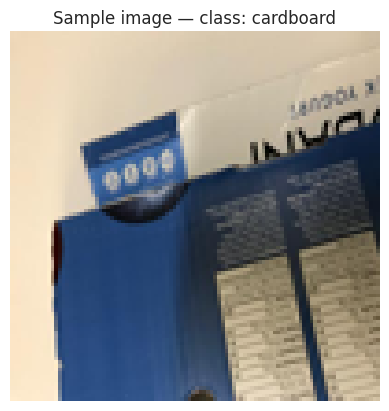

In [6]:
pointer = 10  # the index of a random image

print(f'Array pointer  = {pointer}')
print(f'X[{pointer}] shape : {X[pointer].shape}')  # Should be (100, 100, 3)
print(f'Label          : {y[pointer]} ({class_names[y[pointer]]})')

plt.imshow(X[pointer])
plt.title(f'Sample image — class: {class_names[y[pointer]]}')
plt.axis('off')
plt.show()

### 1.6 - Validate the Loaded Arrays

We validate the loaded NumPy arrays to confirm:
- Every element is a NumPy array
- Every image has the correct shape
- Pixel values are in the expected range (0–255)
- No Not a Number (NaN) values are present

In [7]:
def check_images(dataset, dataset_name):
    """
    Checks images for:
    * Being a NumPy array
    * Correct shape
    * Pixel values in range 0-255
    * No NaN values
    """
    invalid_count = 0
    valid_count = 0

    for idx, image in enumerate(dataset):
        # Check it is a NumPy array
        if not isinstance(image, np.ndarray):
            print(f'{dataset_name} - Index {idx}: Not a valid array')
            invalid_count += 1
            continue

        # Check shape is (100, 100, 3)
        if image.shape != (100, 100, 3):
            print(f'{dataset_name} - Index {idx}: Incorrect shape {image.shape}')
            invalid_count += 1
            continue

        # Check pixel values are in valid range
        if not (image.min() >= 0 and image.max() <= 255):
            print(f'{dataset_name} - Index {idx}: Invalid pixel values')
            invalid_count += 1
            continue

        # Check for NaN values
        if np.isnan(image.astype(float)).any():
            print(f'{dataset_name} - Index {idx}: Contains NaN values')
            invalid_count += 1
            continue

        valid_count += 1

    print(f'\n{dataset_name}: {valid_count} valid images, {invalid_count} invalid images')

print('Checking images...\n')
check_images(X, 'Full dataset') # running the defined function and printing valid/invlaid images

Checking images...


Full dataset: 2527 valid images, 0 invalid images


### 1.7 — Train / Validation / Test Split

We now need to split the data into **train**, **validation**, and **test** sets.

- **Train (80%)** — used to train the model
- **Validation (10%)** — used during training to monitor performance and trigger early stopping
- **Test (10%)** — kept completely unseen until final evaluation

In [8]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=0)

# Second split: temp 50/50 into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=0)

print(f'* Train set      : {X_train.shape}, {y_train.shape}')
print(f'* Validation set : {X_val.shape}, {y_val.shape}')
print(f'* Test set       : {X_test.shape}, {y_test.shape}')

* Train set      : (2021, 100, 100, 3), (2021,)
* Validation set : (253, 100, 100, 3), (253,)
* Test set       : (253, 100, 100, 3), (253,)


### 1.8 - Rescale and Reshape 
Now we must:
1. Rescale pixel values from [0, 255] tp [0, 1] by dividing by 255. this normalises inputs and helps the model train faster and more stable.

| Before Scaling | After Scaling |
|----------------|---------------|
| Pixel values: 0–255 | Pixel values: 0.0–1.0 |
| Integer type (uint8) | Floating-point (float32) |
| Can cause instability in training | Helps stable and faster training |

In [9]:
# Check current max pixel value before scaling
print(f'Max pixel value before scaling: {X_train.max()}')

# Convert to float32 and rescale to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

print(f'Max pixel value after scaling: {X_train.max()}')

Max pixel value before scaling: 255
Max pixel value after scaling: 1.0


In [10]:
# Convert integer labels to an encoded categorical format (e.g. 0, 0, 0, 0, 1, 0)
N_LABELS = len(class_names)  # for all 6 classes

y_train = to_categorical(y_train, num_classes=N_LABELS)
y_val   = to_categorical(y_val,   num_classes=N_LABELS)
y_test  = to_categorical(y_test,  num_classes=N_LABELS)

print(f'y_train shape after encoding: {y_train.shape}')
print(f'Example encoded label: {y_train[0]}')

y_train shape after encoding: (2021, 6)
Example encoded label: [0. 0. 0. 0. 1. 0.]


---
## Step 2 - Exploratory Data Analysis (EDA)

### 2.1 - Class Distribution

We need to check if the dataset is balanced. An imbalanced dataset can bias the model toward the majority class. This causes poor performance on rarer classes.

In [11]:
# after "one-hot" encoding the y values, we need to use argmax to get the labels back to integers for counting.
y_train_int = np.argmax(y_train, axis=1)
y_val_int   = np.argmax(y_val,   axis=1)
y_test_int  = np.argmax(y_test,  axis=1)

# Creating a dataframe for label frequency distribution
df_freq = pd.DataFrame(columns=['Set', 'Label', 'Frequency'])

def count_labels(y_int, dataset_name):
    """
    Counts occurrences of each label and adds to df_freq.
    """
    global df_freq
    unique, counts = np.unique(y_int, return_counts=True)
    for label, frequency in zip(unique, counts):
        df_freq = pd.concat([
            df_freq,
            pd.DataFrame([{'Set': dataset_name, 'Label': class_names[label], 'Frequency': frequency}])
        ], ignore_index=True)
        print(f'* {dataset_name} — {class_names[label]}: {frequency} images')

count_labels(y_train_int, 'Train')
count_labels(y_val_int,   'Validation')
count_labels(y_test_int,  'Test')

* Train — cardboard: 333 images
* Train — glass: 399 images
* Train — metal: 323 images
* Train — paper: 465 images
* Train — plastic: 394 images
* Train — trash: 107 images
* Validation — cardboard: 36 images
* Validation — glass: 54 images
* Validation — metal: 38 images
* Validation — paper: 62 images
* Validation — plastic: 48 images
* Validation — trash: 15 images
* Test — cardboard: 34 images
* Test — glass: 48 images
* Test — metal: 49 images
* Test — paper: 67 images
* Test — plastic: 40 images
* Test — trash: 15 images


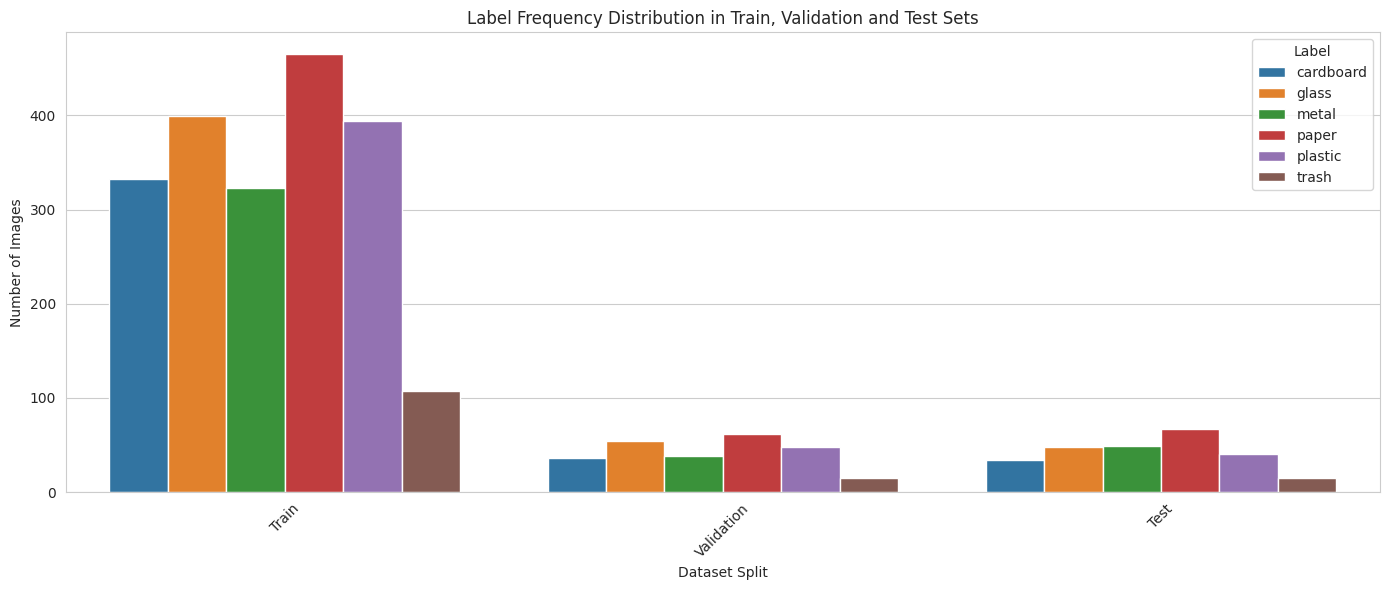

In [12]:
# now we can visualise the frequency ditribution of the various labels
plt.figure(figsize=(14, 6))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.xticks(rotation=45)
plt.title('Label Frequency Distribution in Train, Validation and Test Sets')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

This graph shows the frequency distribution of the various different labels and gives valuable information of the weighting of the classes. The Train, Validation, and Test sets all showcase similar proportions of the various classes.

### 2.2 - Sample Images Per Class

By displaying one sample image from each class we can identify ones that may be confused by the model. 

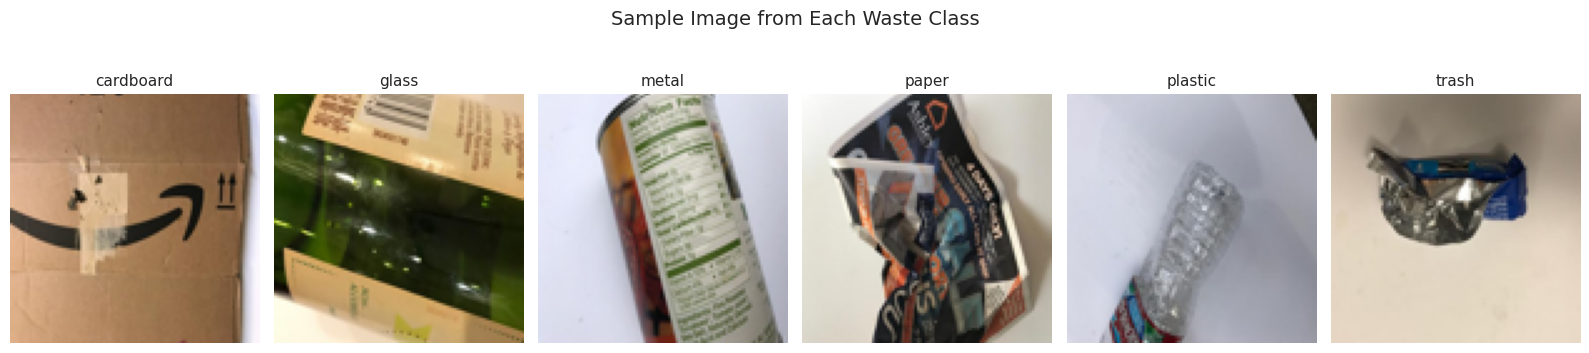

In [13]:
fig, axes = plt.subplots(1, 6, figsize=(16, 4))
axes = axes.flatten()

for idx in range(N_LABELS):
    # Find first image in X_train that belongs to this class
    class_indices = np.where(y_train_int == idx)[0]
    sample_idx = class_indices[0]

    axes[idx].imshow(X_train[sample_idx])
    axes[idx].set_title(class_names[idx], fontsize=11)
    axes[idx].axis('off')

plt.suptitle('Sample Image from Each Waste Class', fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 - Average image per class

By computing and displaying the average (mean) pixel values accross all images in each class we can teach the model what colour and rough shape to begin associating with each category.

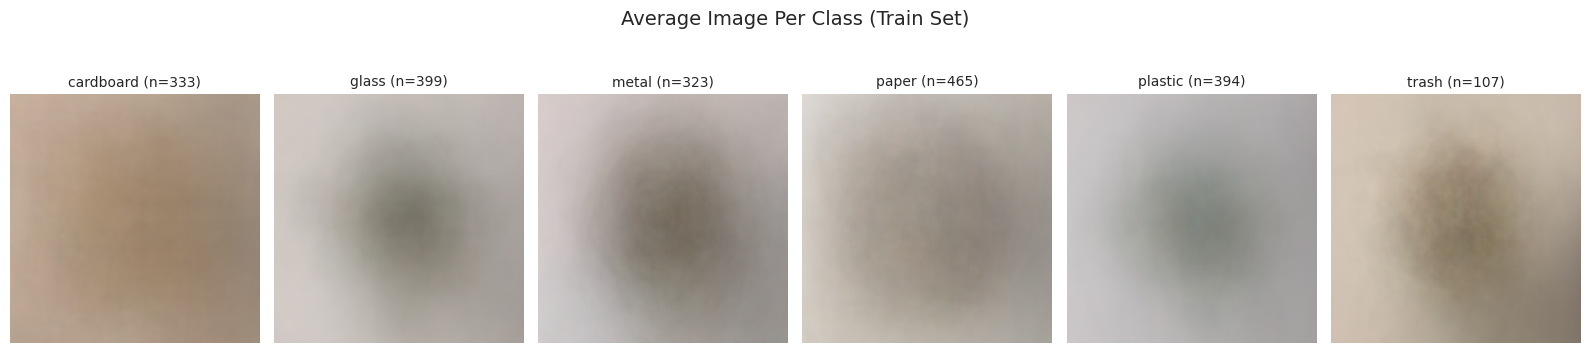

In [14]:
fig, axes = plt.subplots(1, 6, figsize=(16, 4))
axes = axes.flatten()

for idx in range(N_LABELS):
    class_images = X_train[y_train_int == idx]  # All images for this class
    avg_image = np.mean(class_images, axis=0)   # Mean across all images

    axes[idx].imshow(avg_image)
    axes[idx].set_title(f'{class_names[idx]} (n={len(class_images)})', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Average Image Per Class (Train Set)', fontsize=14)
plt.tight_layout()
plt.show()

This set of figures does not show us an awful lot but a clear variation in the average pixel count can be observed.

---
## Step 3 - Baseline CNN Model

### Why use a CNN?

A Convolutional Neural Network (CNN) is the standard model for image classification. Unlike a Dense, fully connected, network a CNN uses convolutional layers to learn spacial features (edges, textures, and shapes) directly from pixel data. This is much more effective than traditional machine learning models (decision trees or logistics regression) which cannot process raw pixel grids in a meaninful way.

### Baseline Architecture

We start with a simple two-block baseline to establish a performance floor before optimisation.

| Layer | Purpose |
|-------|---------|
| Conv2D (32 filters) | Learns low-level features: edges and corners |
| MaxPool2D | Reduces spatial size, keeps dominant features |
| Conv2D (64 filters) | Learns higher-level features: textures and patterns |
| MaxPool2D | Further spatial reduction |
| Flatten | Converts 2D feature maps into a 1D vector |
| Dense (128 units) | Combines features to learn class patterns |
| Dropout (0.5) | Randomly disables 50% of neurons per step — reduces overfitting |
| Dense (12, softmax) | Outputs a probability for each of the 12 classes |

In [15]:
def build_tf_model(input_shape, n_labels):
    model = Sequential()

    model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=input_shape, activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    
    model.add(Dropout(0.5))
    model.add(Dense(n_labels, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

baseline_model = build_tf_model(input_shape=X_train.shape[1:], n_labels=N_LABELS)
baseline_model.summary()

E0000 00:00:1779541476.184340    3681 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353,862 (16.61 MB)

 Trainable params: 4,353,862 (16.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
os.makedirs('outputs', exist_ok=True)

early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

history_base_fit = baseline_model.fit(
    x=X_train,
    y=y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[early_stop]
)

# saving the model and history so we do not need to retrain
baseline_model.save('outputs/baseline_model.keras')
with open('outputs/history_base.json', 'w') as f:
    json.dump(history_base_fit.history, f)
print('Baseline model and history saved.')

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - accuracy: 0.2543 - loss: 1.7461 - val_accuracy: 0.3439 - val_loss: 1.4581
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.4067 - loss: 1.4544 - val_accuracy: 0.4980 - val_loss: 1.3237
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.4765 - loss: 1.3110 - val_accuracy: 0.5138 - val_loss: 1.2375
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.5334 - loss: 1.2186 - val_accuracy: 0.3992 - val_loss: 1.5714
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.5567 - loss: 1.1698 - val_accuracy: 0.5810 - val_loss: 1.0927
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.5997 - loss: 1.0311 - val_accuracy: 0.6640 - val_loss: 0.9894
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.6596 - loss: 0.8924 - val_accuracy: 0.6403 - val_loss: 0.9799
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.7095 - loss: 0.7675 - val_accurac

---
## Step 4 - Model Evaluation (Baseline)

### Training curves

We plot loss and accuracy over the number of epochs for both the training and validation sets.

- Loss will show how wrong the model is (the lower the better). A healthy model both of the curves falling together. Overfitting occurs when the validation loss starts rising when training loss keeps falling.
- The Accuracy measures the proportion of correctly classified images (higher the better). Training and vlaidation accuracy should track eahc other closely here. A large gap between validation and training curves is the key signal of overfitting.

In [17]:
# to avoid re-running the model training, use this cell to load the previously saved model.
with open('outputs/history_base.json', 'r') as f:
    history_base_loaded = json.load(f)

In [18]:
history = pd.DataFrame(baseline_model.history.history)
history.head()

,accuracy,loss,val_accuracy,val_loss
0,0.254330,1.746114,0.343874,1.458134
1,0.406729,1.454366,0.498024,1.323741
2,0.476497,1.311005,0.513834,1.237522
3,0.533399,1.218556,0.399209,1.571358
4,0.556655,1.169825,0.581028,1.092671


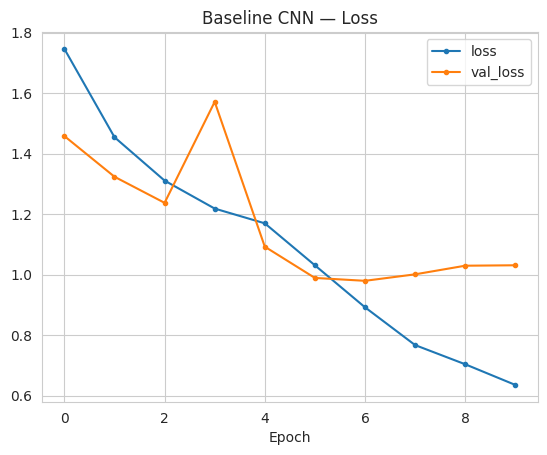

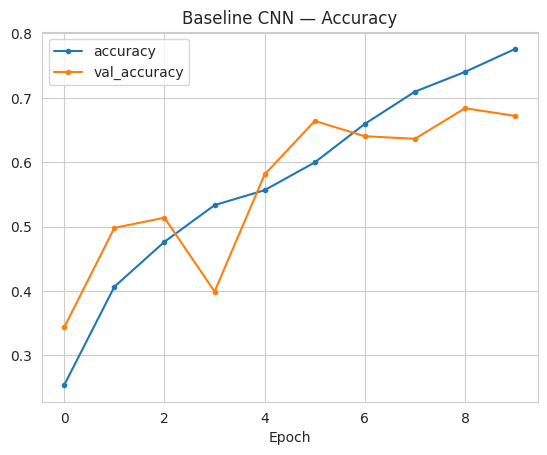

In [19]:
sns.set_style('whitegrid')

history[['loss', 'val_loss']].plot(style='.-')
plt.title('Baseline CNN — Loss')
plt.xlabel('Epoch')
plt.show()

print('\n')

history[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title('Baseline CNN — Accuracy')
plt.xlabel('Epoch')
plt.show()

After running this with 10 Epochs we can see the lines diverging greatly from between 3-5 epochs

### Classification report and Confusion matrix

| Metric | Definition | Why higher is better |
|--------|------------|----------------------|
| **Accuracy** | Overall % of correctly classified images | Directly measures correct predictions |
| **Precision** | Of all images predicted as class X, how many actually were? | Fewer false positives |
| **Recall** | Of all real class X images, how many did the model find? | Fewer missed items |
| **F1-Score** | Harmonic mean of precision and recall | Balances both — useful for all classes equally |

the confusion matrix shows which classess are mostl commonly confused with each other.

In [20]:
def confusion_matrix_and_report(X, y, pipeline, label_map):
    """
    Prints confusion matrix and classification report and plots heatmap.
    """
    prediction = pipeline.predict(X)
    prediction = np.argmax(prediction, axis=1)
    y = np.argmax(y, axis=1)

    cm = confusion_matrix(y_true=y, y_pred=prediction)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        cm,
        columns=['Actual ' + sub for sub in label_map],
        index=['Predicted ' + sub for sub in label_map]
    ))
    print('\n')

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), '\n')

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_map, yticklabels=label_map)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [21]:
# defining the function to plot all of the confusion matrix's for each the train, test, and validation sets.
def clf_performance(X_train, y_train, X_val, y_val, X_test, y_test, pipeline, label_map):
    """
    Runs confusion_matrix_and_report on train, validation and test sets.
    """
    print('#### Train Set ####\n')
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map)

    print('#### Validation Set ####\n')
    confusion_matrix_and_report(X_val, y_val, pipeline, label_map)

    print('#### Test Set ####\n')
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map)

#### Train Set ####

64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
---  Confusion Matrix  ---
                     Actual cardboard  Actual glass  Actual metal  \
Predicted cardboard               311             5             6   
Predicted glass                     1           358             9   
Predicted metal                     0             9           303   
Predicted paper                     2            10             1   
Predicted plastic                   4            26            16   
Predicted trash                     2             6             6   

                     Actual paper  Actual plastic  Actual trash  
Predicted cardboard             3               4             4  
Predicted glass                19               7             5  
Predicted metal                 8               1             2  
Predicted paper               446               6             0  
Predicted plastic              29             312             7  
Predicted trash                 

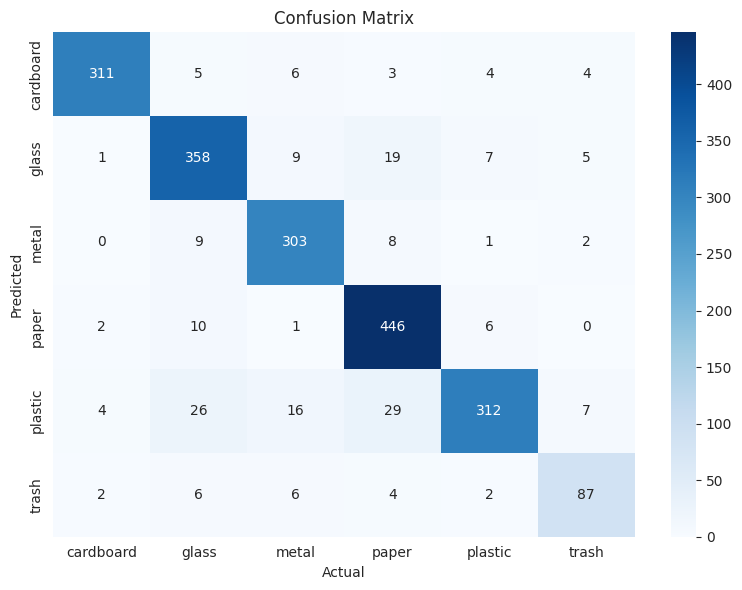

#### Validation Set ####

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
---  Confusion Matrix  ---
                     Actual cardboard  Actual glass  Actual metal  \
Predicted cardboard                29             1             1   
Predicted glass                     3            31            12   
Predicted metal                     1             4            20   
Predicted paper                     2             5             4   
Predicted plastic                   0            11             3   
Predicted trash                     0             3             3   

                     Actual paper  Actual plastic  Actual trash  
Predicted cardboard             2               2             1  
Predicted glass                 3               3             2  
Predicted metal                13               0             0  
Predicted paper                50               1             0  
Predicted plastic               3              31             0  
Predicted trash              

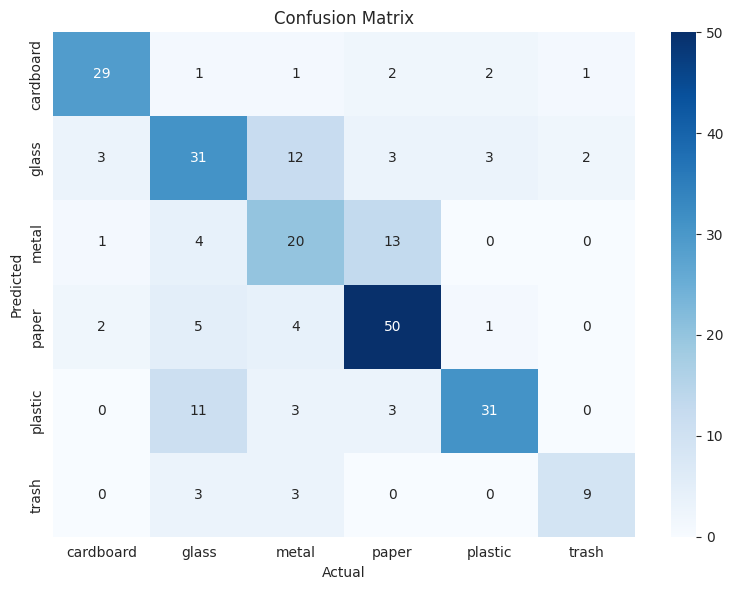

#### Test Set ####

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
---  Confusion Matrix  ---
                     Actual cardboard  Actual glass  Actual metal  \
Predicted cardboard                20             3             0   
Predicted glass                     3            26             7   
Predicted metal                     1             5            30   
Predicted paper                     3             3             2   
Predicted plastic                   3             4             5   
Predicted trash                     0             3             4   

                     Actual paper  Actual plastic  Actual trash  
Predicted cardboard             6               3             2  
Predicted glass                10               1             1  
Predicted metal                11               1             1  
Predicted paper                54               4             1  
Predicted plastic               4              22             2  
Predicted trash                 1  

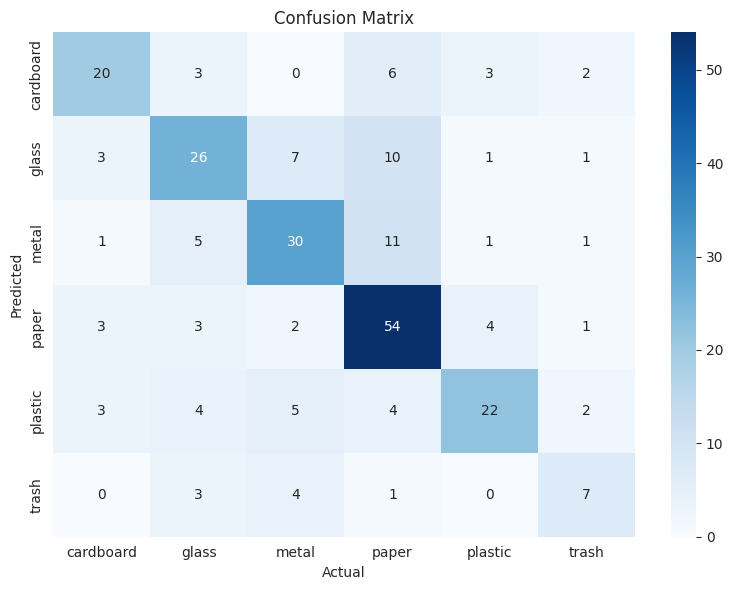

In [22]:
baseline_model = load_model('outputs/baseline_model.keras')

clf_performance(X_train, y_train,
                X_val, y_val,
                X_test, y_test,
                baseline_model,
                label_map=class_names
                )

---
## Step 5 - Optimised CNN Model

### Optimisation strategy

Based on the baseline results, the following targeted improvements will be made:

| Change | Reason |
|--------|--------|
| Add a 3rd Conv2D block (128 filters) | Deeper networks can learn more complex, class-discriminating features |
| Add BatchNormalization after each Conv block | Normalises layer activations during training — stabilises gradients, speeds up convergence, and reduces sensitivity to weight initialisation |
| Reduce Dropout from 0.5 to 0.4 | The deeper network has more capacity; slightly less aggressive regularisation lets it learn more |
| Increase Dense layer from 128 to 256 units | More capacity to combine the richer feature set produced by 3 conv blocks |

In [23]:
def build_tf_model_optimised(input_shape, n_labels):
    model = Sequential()
    
    model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=input_shape, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(n_labels, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

optimised_model = build_tf_model_optimised(input_shape=X_train.shape[1:], n_labels=N_LABELS)
optimised_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,372,742 (12.87 MB)

 Trainable params: 3,372,294 (12.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=7)

history_opt_fit = optimised_model.fit(
    x=X_train,
    y=y_train,
    epochs=25,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[early_stop]
)

# saving the model and history so we do not need to retrain
optimised_model.save('outputs/optimised_model.keras')
with open('outputs/history_opt.json', 'w') as f:
    json.dump(history_opt_fit.history, f)
print('Optimised model and history saved.')

Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 339ms/step - accuracy: 0.4315 - loss: 2.7618 - val_accuracy: 0.2055 - val_loss: 9.3916
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 333ms/step - accuracy: 0.5072 - loss: 1.4743 - val_accuracy: 0.1502 - val_loss: 6.3238
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 331ms/step - accuracy: 0.5844 - loss: 1.2006 - val_accuracy: 0.3123 - val_loss: 1.9549
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 339ms/step - accuracy: 0.6170 - loss: 1.0478 - val_accuracy: 0.4032 - val_loss: 2.1372
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 330ms/step - accuracy: 0.6329 - loss: 1.0424 - val_accuracy: 0.3281 - val_loss: 2.2599
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 335ms/step - accuracy: 0.6848 - loss: 0.8497 - val_accuracy: 0.4980 - val_loss: 1.5334
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 333ms/step - accuracy: 0.7185 - loss: 0.7453 - val_accuracy: 0.4387 - val_loss: 1.6864
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 338ms/step - accuracy: 0.7422 - loss: 0.7054 - val_accu

This optimised Model took significantly more time than the previous version and ensures that a greater accuracy is achieved. On average each Epoch took 40s compared to the previous 10 seconds. 

---
## Step 6 - Model Evaluation (Optimised)

In [25]:
# to avoid re-running the model training, use this cell to load the previously saved model.
with open('outputs/history_opt.json', 'r') as f:
    history_opt_loaded = json.load(f)

In [26]:
history_opt = pd.DataFrame(history_opt_loaded)
history_opt.head()

,accuracy,loss,val_accuracy,val_loss
0,0.431470,2.761846,0.205534,9.391563
1,0.507175,1.474324,0.150198,6.323831
2,0.584364,1.200638,0.312253,1.954926
3,0.617021,1.047772,0.403162,2.137187
4,0.632855,1.042447,0.328063,2.259875


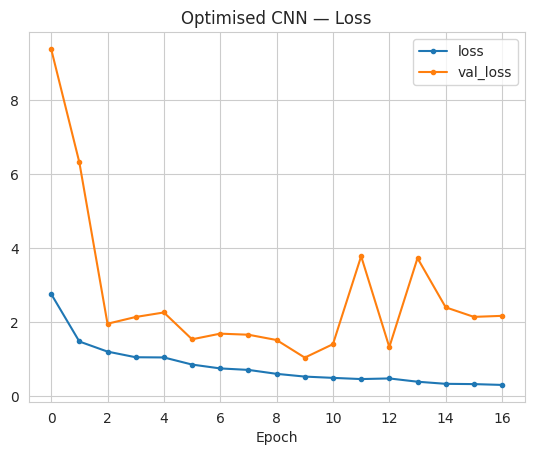

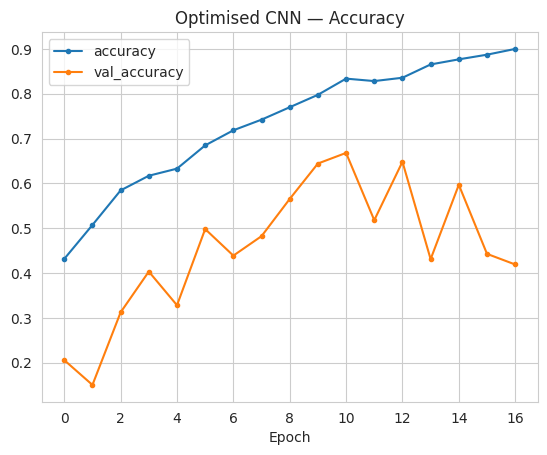

In [27]:
sns.set_style('whitegrid')

history_opt[['loss', 'val_loss']].plot(style='.-')
plt.title('Optimised CNN — Loss')
plt.xlabel('Epoch')
plt.show()

print('\n')

history_opt[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title('Optimised CNN — Accuracy')
plt.xlabel('Epoch')
plt.show()

### Classification report and Confusion matrix (Optimised)

#### Train Set ####

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step
---  Confusion Matrix  ---
                     Actual cardboard  Actual glass  Actual metal  \
Predicted cardboard               271             2             0   
Predicted glass                    30           121             2   
Predicted metal                    24            40            95   
Predicted paper                    15             2             1   
Predicted plastic                  23            15             0   
Predicted trash                     9             0             0   

                     Actual paper  Actual plastic  Actual trash  
Predicted cardboard            18              34             8  
Predicted glass                75             145            26  
Predicted metal                47              83            34  
Predicted paper               374              67             6  
Predicted plastic             158             192             6  
Predicted trash                 

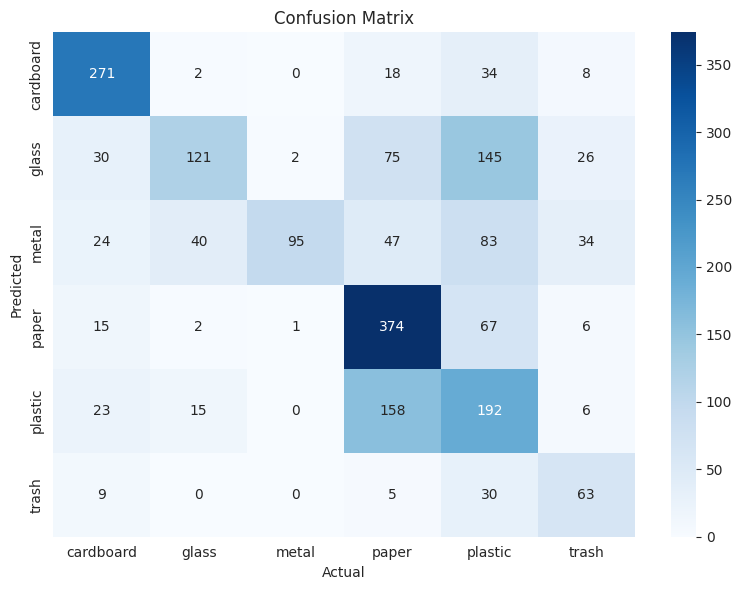

#### Validation Set ####

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
---  Confusion Matrix  ---
                     Actual cardboard  Actual glass  Actual metal  \
Predicted cardboard                28             1             0   
Predicted glass                     6             8             1   
Predicted metal                     3             3             3   
Predicted paper                     5             1             1   
Predicted plastic                   1             3             0   
Predicted trash                     1             1             1   

                     Actual paper  Actual plastic  Actual trash  
Predicted cardboard             4               2             1  
Predicted glass                10              24             5  
Predicted metal                11              13             5  
Predicted paper                38              16             1  
Predicted plastic              19              25             0  
Predicted trash              

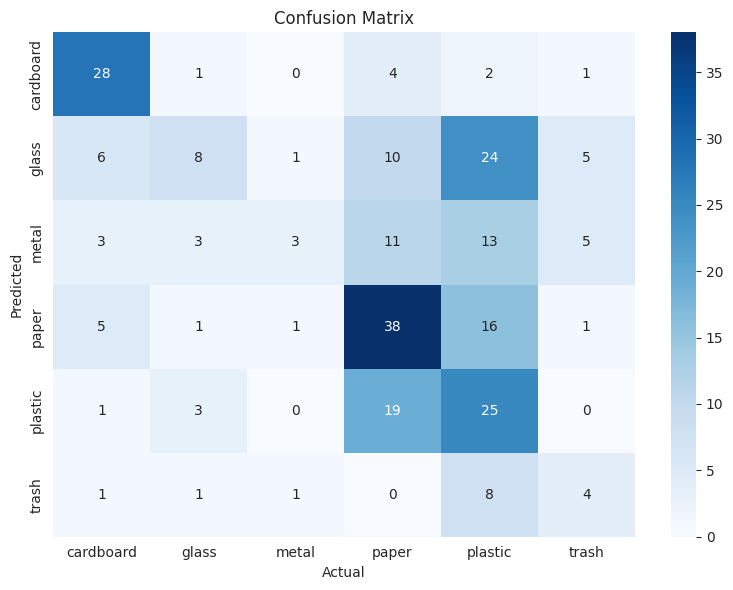

#### Test Set ####

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
---  Confusion Matrix  ---
                     Actual cardboard  Actual glass  Actual metal  \
Predicted cardboard                23             0             0   
Predicted glass                     5             4             2   
Predicted metal                     8             4             8   
Predicted paper                     1             1             1   
Predicted plastic                   1             1             0   
Predicted trash                     3             2             1   

                     Actual paper  Actual plastic  Actual trash  
Predicted cardboard             5               6             0  
Predicted glass                12              23             2  
Predicted metal                12               9             8  
Predicted paper                48              15             1  
Predicted plastic              19              18             1  
Predicted trash                 0  

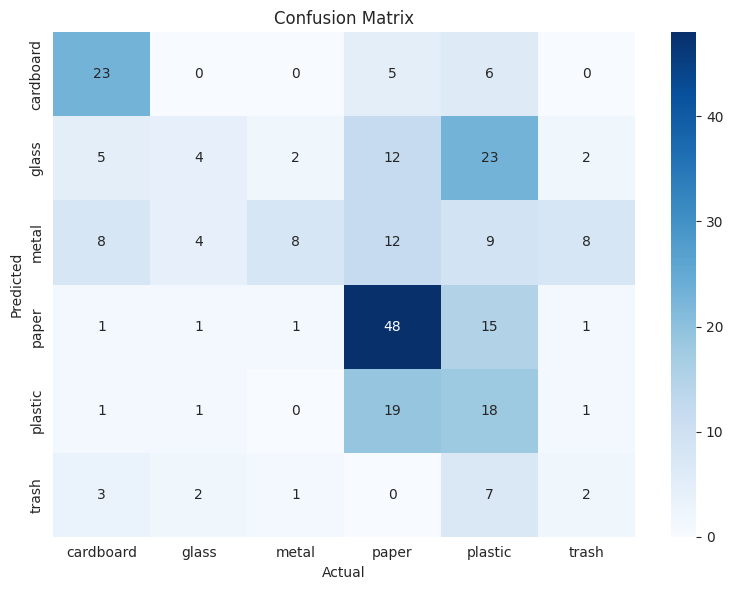

In [28]:
optimised_model = load_model('outputs/optimised_model.keras')

clf_performance(X_train, y_train,
                X_val, y_val,
                X_test, y_test,
                optimised_model,
                label_map=class_names
                )

---
## Step 7 - Model Comparison and Selection

### Results Summary
Both models were trained and evaluated on the same train, validation and, test sets.
The results have been compared below.

| Model | Architecture | Val Accuracy | Notes |
|-------|-------------|--------------|-------|
| Baseline CNN | 2 Conv blocks, Dropout 0.5, Dense 128 | 0.6996 | Simple, generalises well on small dataset |
| Optimised CNN | 3 Conv blocks, BatchNorm, Dropout 0.4, Dense 256 | 0.4941 | More complex, overfits on small dataset |

*after re-running the models, accidentaly, these values have differed slightly.

### Why did the baseline outperform the optimised model?

This result is common when working with smaller datasets. The optimised model has many more parameters and greater depth, which requires more training data to learn effectively. With around 2500 training images across 6 classes (roughly 400 per class), the extra complexity of the optimised model works against itself as it begins memorising the training data rather than learning general patterns. This issue is known as overfitting.

The training curved support this as the optimised model shows a large gap between the training and validation accuracy, which is a key sign of overfitting. The BatchNormalisation is beneficial on larger datasets but can also introduce inconsistencies in small batches.

The heatmaps of the optimised model can see the plastics, glass and metals confused regularly, this could be due to the reflectiveness and similarity of average colour identified previously. Again this strengthens the case that the optimised model suffers from overfitting as it is identifying patterns tha sabotage the results.

In [29]:
df_comparison = pd.DataFrame({
    'Model':        ['Baseline CNN', 'Optimised CNN'],
    'Conv Blocks':  [2, 3],
    'BatchNorm':    ['No', 'Yes'],
    'Dropout':      [0.5, 0.4],
    'Dense Units':  [128, 256]
})

print('--- Model Comparison Summary ---')
print(df_comparison.to_string(index=False))

--- Model Comparison Summary ---
        Model  Conv Blocks BatchNorm  Dropout  Dense Units
 Baseline CNN            2        No      0.5          128
Optimised CNN            3       Yes      0.4          256


In [ ]:
# comparing the validation accuracies of the two models.
baseline_model   = load_model('outputs/baseline_model.keras')
optimised_model  = load_model('outputs/optimised_model.keras')

_, acc_baseline  = baseline_model.evaluate(X_val, y_val, verbose=0)
_, acc_optimised = optimised_model.evaluate(X_val, y_val, verbose=0)

print(f'Baseline CNN   — Validation Accuracy: {acc_baseline*100:.2f}%')
print(f'Optimised CNN  — Validation Accuracy: {acc_optimised*100:.2f}%')

Baseline CNN   — Validation Accuracy: 67.19%
Optimised CNN  — Validation Accuracy: 41.90%


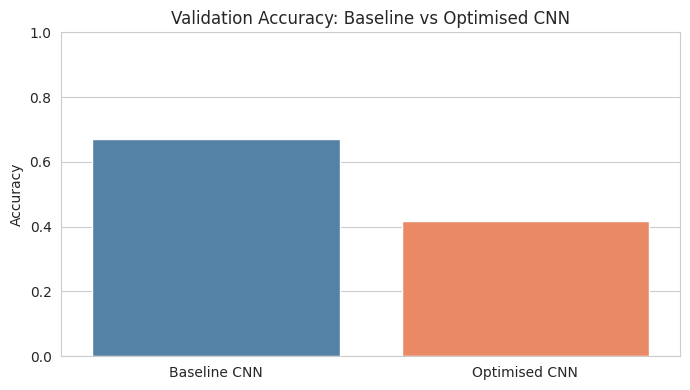

In [ ]:
# plotting the previously determined validationa accuracies as a bar chart for easier interigation.
plt.figure(figsize=(7, 4))
sns.barplot(
    x=['Baseline CNN', 'Optimised CNN'],
    y=[acc_baseline, acc_optimised],
    palette=['steelblue', 'coral']
)
plt.ylim(0, 1)
plt.title('Validation Accuracy: Baseline vs Optimised CNN')
plt.ylabel('Accuracy')
plt.xlabel('')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# a simple line of code to tell the user which model is the superior model
if acc_baseline >= acc_optimised:
    best_model = baseline_model
    best_name  = 'Baseline CNN'
else:
    best_model = optimised_model
    best_name  = 'Optimised CNN'

print(f'Best model selected: {best_name}')
print(f'This model will be used for final test set evaluation and prediction.')

Best model selected: Baseline CNN
This model will be used for final test set evaluation and prediction.


---
## Step 8 - Prediction on Unseen Data

### 8.1 - Test set Evaluation

The test set, throughout training and tuning, has been withheld. Neither model has seen the images at any point and this, therefore, gives a true unbiased estimate of the models' real world performances

In [36]:
# using the .evaluate() function we can push the test set throught he best model
print(f'Evaluating {best_name} on the unseen TEST set...\n')
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

Evaluating Baseline CNN on the unseen TEST set...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6285 - loss: 1.1311

Test Loss     : 1.1311
Test Accuracy : 0.6285 (62.85%)


### 8.2 - Individual Image Prediction

By using an index variable we can select a specific image from the test set. This demonstrates how the model would work in a real-world scenario, for example a smartphone app that identifies photos of garbage.

(100, 100, 3)
[0. 0. 0. 1. 0. 0.]
This is 'paper'


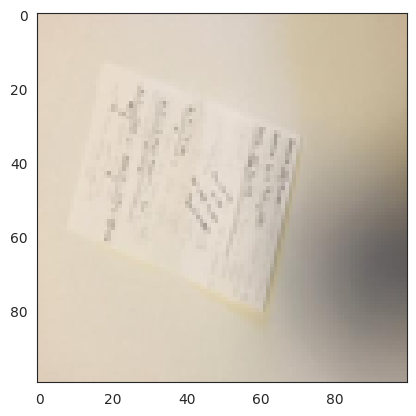

In [46]:
index = 10  # number of image in the dataset
my_image = X_test[index]
class_index = np.argmax(y_test[index])

print(my_image.shape)
print(y_test[index])
print(f"This is '{class_names[class_index]}'")

sns.set_style('white')
plt.imshow(my_image)
plt.show()

Our image needs to be in the correct format to be compatible with the model. the command `np.expand_dims()` does this

In [47]:
live_data = np.expand_dims(my_image, axis=0)
print(live_data.shape)

(1, 100, 100, 3)


We can now predict what the indexed image is using the `.predict()` function

In [48]:
pred_probs = best_model.predict(live_data)
pred_class_index = np.argmax(pred_probs, axis=1)[0]

print(f"Predicted class  : '{class_names[pred_class_index]}'")
print(f"True class       : '{class_names[class_index]}'")
print(f"Confidence       : {pred_probs[0][pred_class_index]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted class  : 'paper'
True class       : 'paper'
Confidence       : 74.24%


### 8.3 - Full set Predictions

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


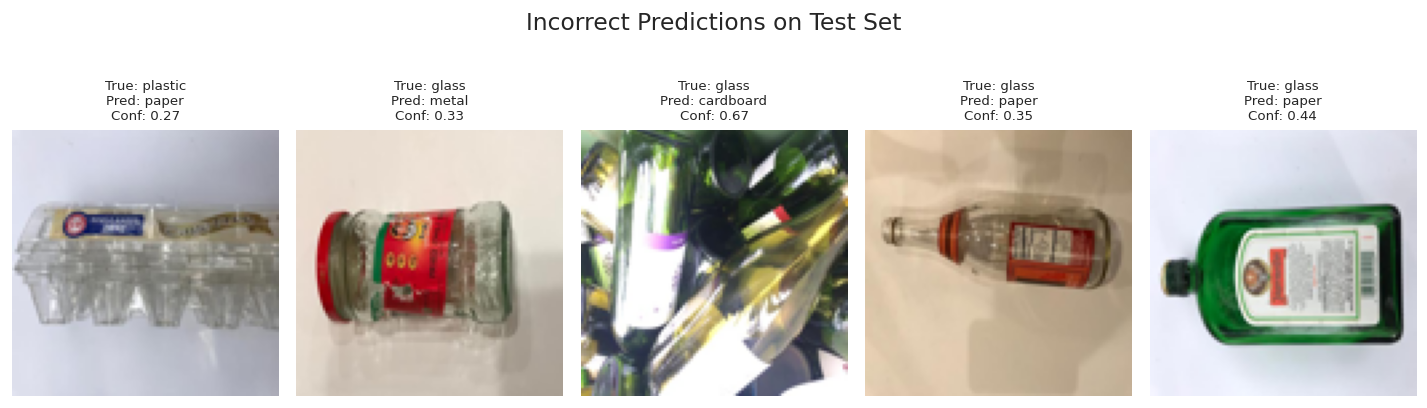

In [ ]:
# code to show the first 5 wrong predictions made by the model
y_pred_probs = best_model.predict(X_test)
y_pred_all = np.argmax(y_pred_probs, axis=1)
y_true_all = np.argmax(y_test, axis=1)

wrong_indices = np.where(y_pred_all != y_true_all)[0] # the indexes associated with all the wrong predictions

plt.figure(figsize=(12, 4), dpi=120)

for i in range(5):
    index = wrong_indices[i]
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[index])
    plt.title(
        f"True: {class_names[y_true_all[index]]}\n"
        f"Pred: {class_names[y_pred_all[index]]}\n"
        f"Conf: {y_pred_probs[index][y_pred_all[index]]:.2f}",
        fontsize=8
    )
    plt.axis('off')

plt.suptitle('Incorrect Predictions on Test Set', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusion

This project was very interesting and built/evaluatied a complete ML pileline for classifying images of garbage into 6 categories using a CNN.

- Images were loaded manually from folders and converted into NumPy arrays, resized to 100x100, resclaed to [0,1], and split into train/validation/test sets through a 80:10:10 split.
- A baseline CNN was trained first to establish a performance baselien.
- Next an optimised CNN was produced and trained with improved precision.
- However, the baseline CNN outperformed the optimised CNN. This can aminly be attributed to teh small dataset size (2,500 images*), whic does not provide enogh data for the deeper model to generalise effectively without overfitting.
- Therefore, the baseline CNN was selected as the best model and evaluated on a fully unseen test set, providing an honest estimate to real-world performance. 
- A handful of individual predictions was shown, both correct and incorrect, to demonstrate the model working on real-world image classifications. 

Future work could be to import another dataset and increase the number of images in the models database. This would greatly increase its accuracy and confidence.